# Adaptive decomposition with hyperparameter optimisation

This notebook compares **no adaptation** against **adaptation with Bayesian hyperparameter optimisation** using `optimize_adapt_decomp` / `run_with_optimization` from `adapt_decomp.optimize`.

The same simulated dataset from `test.ipynb` is used (index flexion at 15% MVC, wrist flexing 0 → −40° in a staircase pattern). The first plateau (30 s) is the calibration segment; adaptation runs over the full 190 s recording.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, run_with_optimization
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

In [2]:
import json

# ── Run control ──────────────────────────────────────────────────────────────
RUN_OPTIMISATION = True    # True = run Optuna; False = load saved results
RESULTS_DIR = Path('..', 'data', 'example', 'opt_results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _to_json_safe(v):
    if isinstance(v, torch.Tensor):
        return v.item()
    if hasattr(v, 'item'):
        return v.item()
    return v

## 1. Load data

In [3]:
path_emg    = Path('..', 'data', 'example', 'data_sim.hdf5')
path_decomp = Path('..', 'data', 'example', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)
print(data.keys())

n_units = data['sep_vectors'].shape[0]
print(f'Units: {n_units},  samples: {data["emg"].shape[0]},  fs: {data["fs"]} Hz')

dict_keys(['emg', 'timestamps', 'fs', 'force_profile', 'angle_profile', 'ch_map', 'whitening', 'sep_vectors', 'base_centr', 'spikes_centr', 'ext_fact', 'emg_calib', 'ipts_calib', 'spikes_calib', 'spikes_gt', 'preprocess'])
Units: 18,  samples: 389120,  fs: 2048 Hz


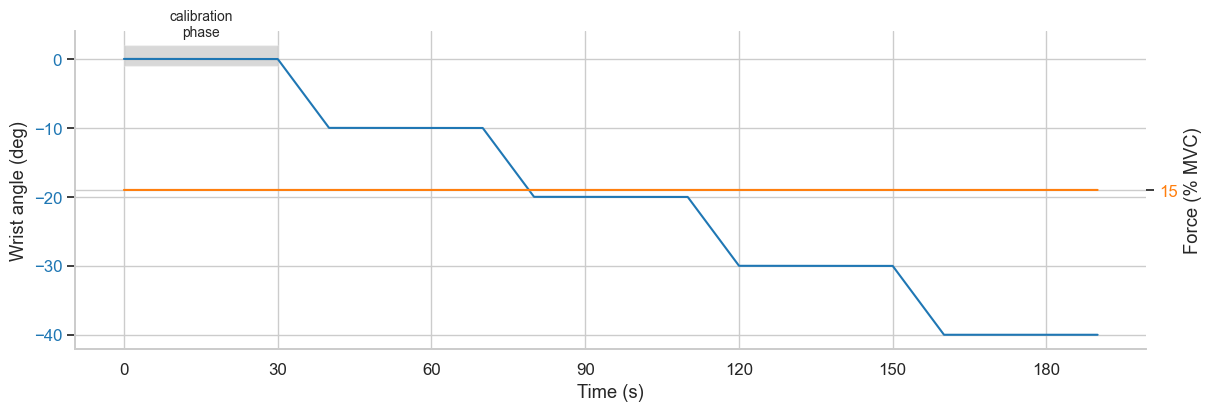

In [4]:
fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, 191, 30))
plt.show()

## 2. No adaptation

All adaptation flags disabled; the calibration whitening matrix and separation vectors are applied unchanged to the full recording.

In [5]:
cfg_no = Config()
cfg_no.ext_fact       = data['ext_fact']
cfg_no.adapt_wh       = False
cfg_no.adapt_sv       = False
cfg_no.adapt_sd       = False
cfg_no.compute_loss   = True
cfg_no.device         = 'cpu'
cfg_no.contrast_scope = 'spike_based'
cfg_no.wh_mode        = 'kl_to_identity'

dec_no = AdaptDecomp(
    emg          = data['emg'].clone(),
    whitening    = data['whitening'].clone(),
    sep_vectors  = data['sep_vectors'].clone(),
    base_centr   = data['base_centr'].clone(),
    spikes_centr = data['spikes_centr'].clone(),
    emg_calib    = data['emg_calib'].clone(),
    ipts_calib   = data['ipts_calib'].clone(),
    spikes_calib = data['spikes_calib'].clone(),
    preprocess   = data['preprocess'],
    config       = cfg_no,
)
out_no = dec_no.run()
print('No-adaptation run complete.')

No-adaptation run complete.


## 3. Adaptation with Bayesian hyperparameter optimisation

`optimize_adapt_decomp` wraps Optuna TPE over a user-specified `param_space`.  
The objective is the combined z-scored whitening loss + contrast loss: both are normalised by their calibration standard deviation so `eta_v` and `eta_b` become scale-free across contractions.

The function reuses a single `AdaptDecomp` instance across all trials, resetting calibration state between runs via `_reset_params()`.

In [6]:
# Parameters held fixed for every trial
base_config = {
    'ext_fact':       data['ext_fact'],
    'adapt_wh':       True,
    'adapt_sv':       True,
    'adapt_sd':       True,
    'contrast_scope': 'spike_based',
    'wh_mode':        'kl_to_identity',
    'compute_loss':   True,
    'device':         'cpu',
    'eta_v':           1,
    'eta_b':           1,
    'trace_check':     True,
    'log_wh_trace':    True,
}

param_space = {
    'max_rel_delta_v': ('log_float', 1e-4, 1.0),
    'max_rel_delta_b': ('log_float', 1e-4, 1.0),
}

_cfg_path   = RESULTS_DIR / 'best_config.json'
_study_path = RESULTS_DIR / 'study_trials.csv'

if RUN_OPTIMISATION:
    best_config, study = optimize_adapt_decomp(
        emg          = data['emg'],
        whitening    = data['whitening'],
        sep_vectors  = data['sep_vectors'],
        base_centr   = data['base_centr'],
        spikes_centr = data['spikes_centr'],
        emg_calib    = data['emg_calib'],
        ipts_calib   = data['ipts_calib'],
        spikes_calib = data['spikes_calib'],
        param_space  = param_space,
        base_config  = base_config,
        n_trials     = 30,
        preprocess   = data['preprocess'],
    )
    with open(_cfg_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config.items()}, f, indent=2)
    pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                  for t in study.trials if t.value is not None]).to_csv(_study_path, index=False)
    print(f'Saved → {_cfg_path}')
else:
    with open(_cfg_path) as f:
        best_config = json.load(f)
    study = None
    print(f'Loaded from {_cfg_path}')

print('Best hyperparameters:')
for k, v in best_config.items():
    if k in param_space:
        print(f'  {k}: {v:.4e}')

[W 2026-05-19 12:40:13,947] Trial 9 failed with parameters: {'max_rel_delta_v': 0.002222926300463712, 'max_rel_delta_b': 0.01158829580481964} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/miniconda3/envs/decomposition/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/Users/irene/Documents/work_local/decomposition/lib/adapt_decomp/src/adapt_decomp/optimize.py", line 94, in objective
    return adapter.run_optimisation(config_overrides=overrides)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/irene/Documents/work_local/decomposition/lib/adapt_decomp/src/adapt_decomp/adaptation.py", line 495, in run_optimisation
    spikes, ipts = self.run_decomp(emg_batch, i)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/irene/Documents/work_local/decomposition/lib/adapt_decomp/src/adapt_decomp/

KeyboardInterrupt: 

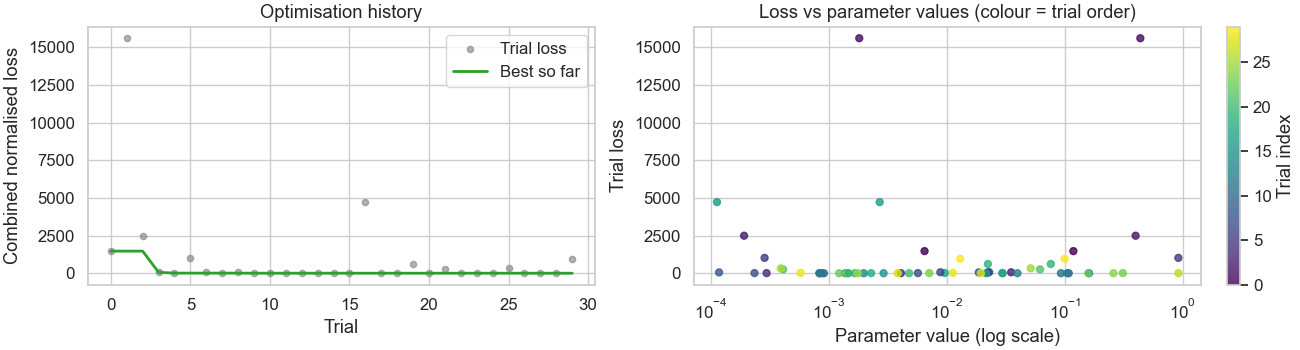

In [ ]:
%matplotlib widget
if study is None:
    print('Optimisation history not available (results loaded from file).')
else:
    values = [t.value for t in study.trials]
    best_so_far = np.minimum.accumulate(values)

    fig, axs = plt.subplots(1, 2, figsize=(13, 3.5), layout='constrained')

    axs[0].scatter(range(len(values)), values, s=20, alpha=0.6, color='tab:grey', label='Trial loss')
    axs[0].plot(range(len(values)), best_so_far, color='tab:green', linewidth=2, label='Best so far')
    axs[0].set(xlabel='Trial', ylabel='Combined normalised loss', title='Optimisation history')
    axs[0].legend()

    param_names = list(param_space.keys())
    for i, name in enumerate(param_names):
        vals = [t.params[name] for t in study.trials if name in t.params]
        cols = [t.value      for t in study.trials if name in t.params]
        sc = axs[1].scatter(vals, cols, c=range(len(vals)), cmap='viridis', s=25, alpha=0.8,
                            label=name if i == 0 else None)

    axs[1].set(xlabel='Parameter value (log scale)', xscale='log',
               ylabel='Trial loss', title='Loss vs parameter values (colour = trial order)')
    plt.colorbar(sc, ax=axs[1], label='Trial index')
    plt.show()

Apply the best configuration and run the adaptation to obtain the full output dict (losses, timing, IPTs, spikes).

In [ ]:
_out_opt_path = RESULTS_DIR / 'out_opt.pt'

if RUN_OPTIMISATION:
    cfg_opt = Config()
    for k, v in best_config.items():
        setattr(cfg_opt, k, v)

    dec_opt = AdaptDecomp(
        emg          = data['emg'].clone(),
        whitening    = data['whitening'].clone(),
        sep_vectors  = data['sep_vectors'].clone(),
        base_centr   = data['base_centr'].clone(),
        spikes_centr = data['spikes_centr'].clone(),
        emg_calib    = data['emg_calib'].clone(),
        ipts_calib   = data['ipts_calib'].clone(),
        spikes_calib = data['spikes_calib'].clone(),
        preprocess   = data['preprocess'],
        config       = cfg_opt,
    )
    out_opt = dec_opt.run()
    torch.save(out_opt, _out_opt_path)
    print(f'Saved → {_out_opt_path}')
else:
    out_opt = torch.load(_out_opt_path, weights_only=False)
    print(f'Loaded from {_out_opt_path}')

print('Optimized adaptation run complete.')

Saved → ../data/example/opt_results/out_opt.pt
Optimized adaptation run complete.


In [ ]:
# Equivalent one-liner (re-runs the full pipeline internally; shown for reference):
#
# out_opt, best_config, study = run_with_optimization(
#     emg          = data['emg'],
#     whitening    = data['whitening'],
#     sep_vectors  = data['sep_vectors'],
#     base_centr   = data['base_centr'],
#     spikes_centr = data['spikes_centr'],
#     emg_calib    = data['emg_calib'],
#     ipts_calib   = data['ipts_calib'],
#     spikes_calib = data['spikes_calib'],
#     param_space  = param_space,
#     base_config  = base_config,
#     n_trials     = 30,
#     preprocess   = data['preprocess'],
# )
#
# `out_opt` is the raw AdaptDecomp.run() output dict (spikes, ipts, wh_loss, …).

## 4. Execution time per batch

In [ ]:
conditions = {'No adaptation': out_no, 'Optimized adaptation': out_opt}

for label, out in conditions.items():
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()

No adaptation
-------------
       wh_time_ms: 10.630 ± 2.189 ms
       sv_time_ms: 0.082 ± 0.032 ms
       sd_time_ms: 0.644 ± 0.619 ms
    total_time_ms: 11.357 ± 2.378 ms

Optimized adaptation
--------------------
       wh_time_ms: 13.269 ± 1.937 ms
       sv_time_ms: 0.611 ± 0.262 ms
       sd_time_ms: 0.629 ± 0.304 ms
    total_time_ms: 14.509 ± 1.961 ms



## 5. Loss trajectories

Both losses are z-scored by their calibration standard deviation (`sigma_K_cal` and `sigma_kappa_cal`), making them dimensionless and directly comparable. A loss near zero means the online statistics match calibration; large values indicate drift.

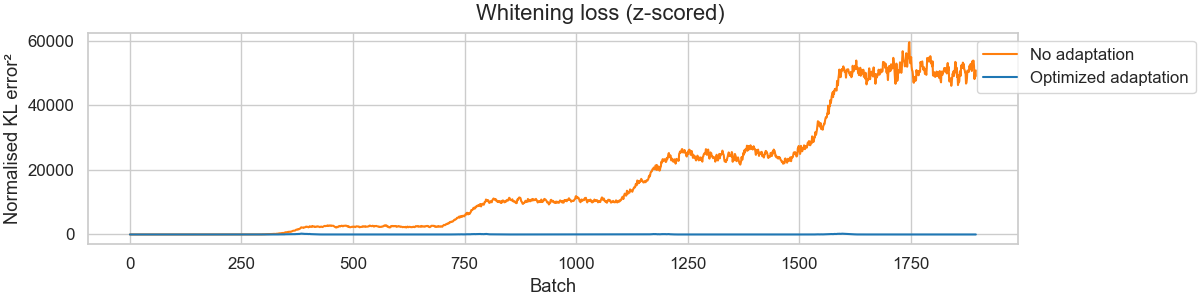

In [ ]:
conditions = {'No adaptation': out_no, 'Optimized adaptation': out_opt}
colors = {'No adaptation': 'tab:orange', 'Optimized adaptation': 'tab:blue'}

fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label, out in conditions.items():
    ax.plot(out['wh_loss'][10:-1], label=label, color=colors[label])
ax.set(xlabel='Batch', ylabel='Normalised KL error²')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.suptitle('Whitening loss (z-scored)')
plt.show()

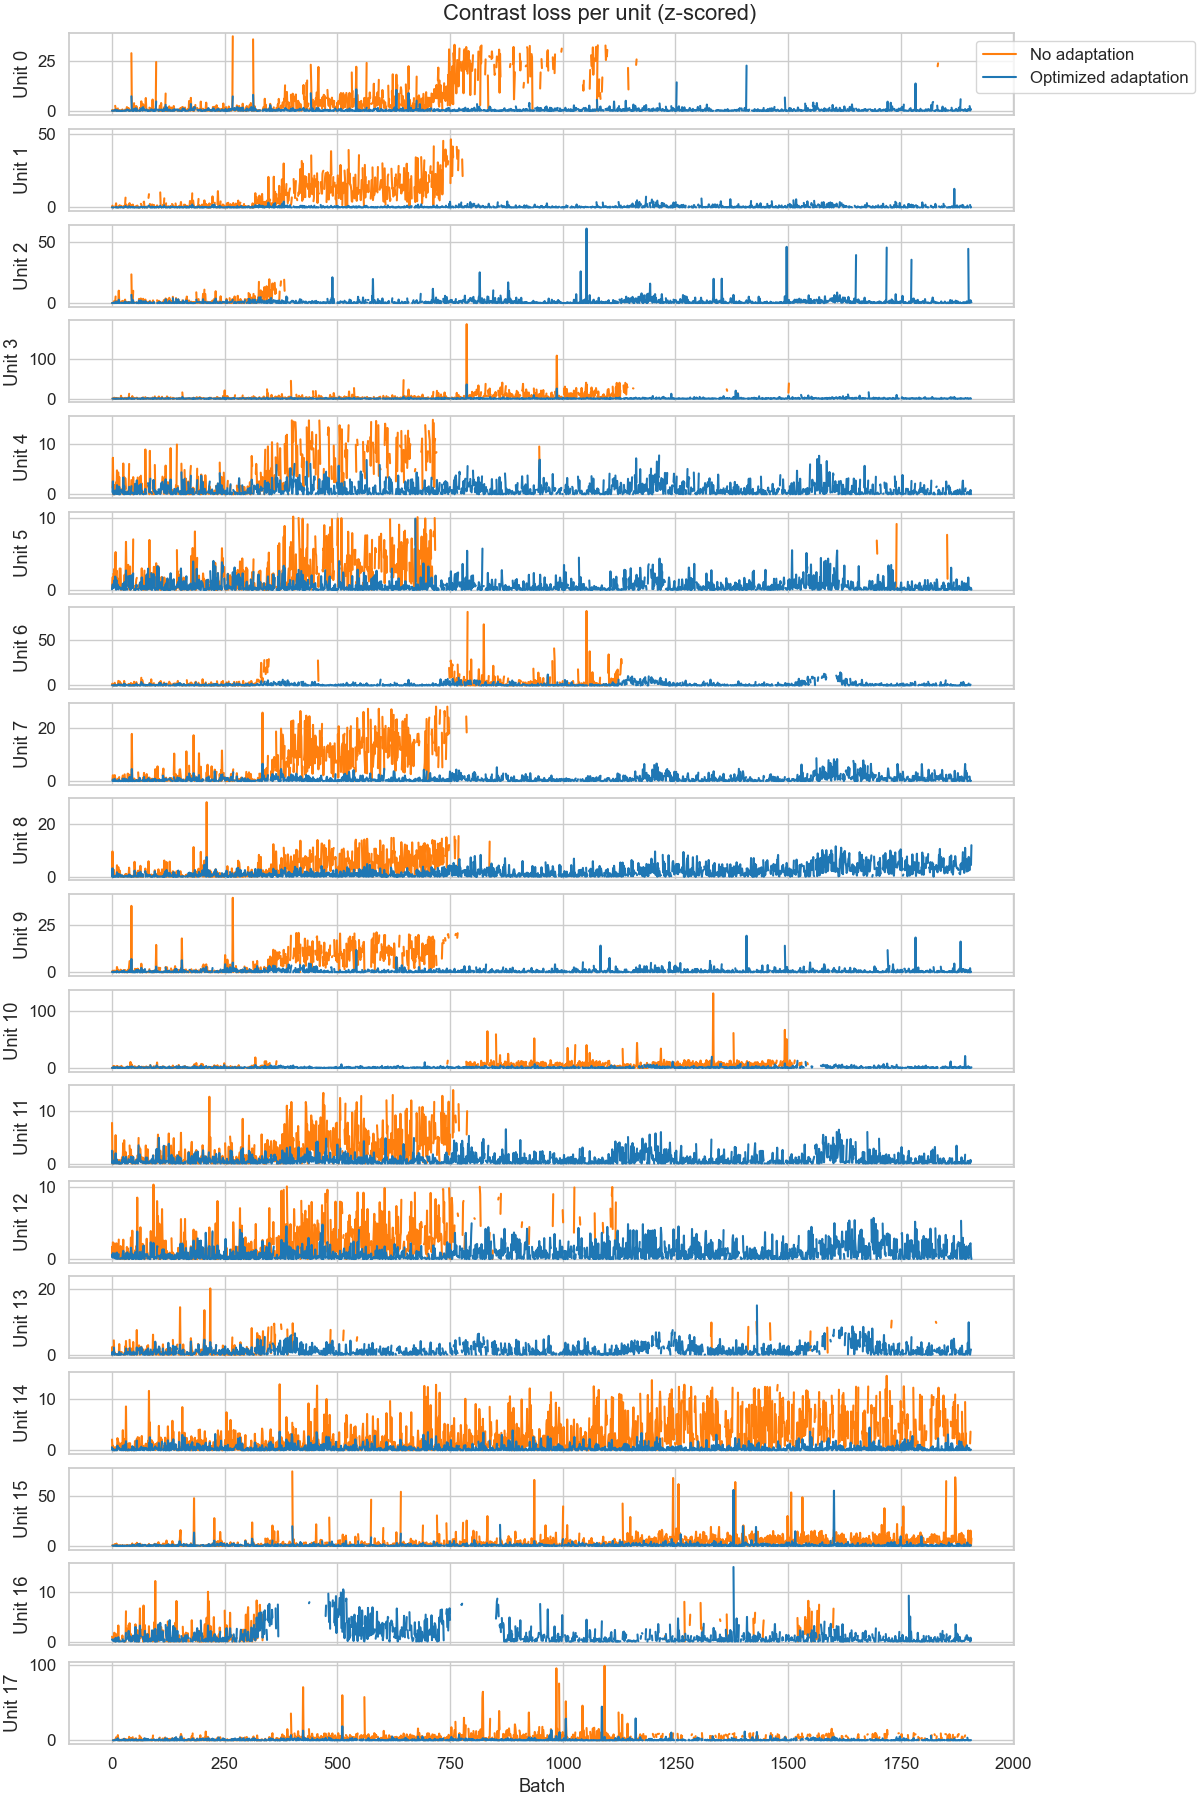

In [ ]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label, out in conditions.items():
        axs[u].plot(out['sv_loss'][:, u], label=label, color=colors[label])
    axs[u].set(ylabel=f'Unit {u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast loss per unit (z-scored)')
plt.show()

## 6. IPTs and spike trains

Window at maximum wrist angle deviation (180–190 s).

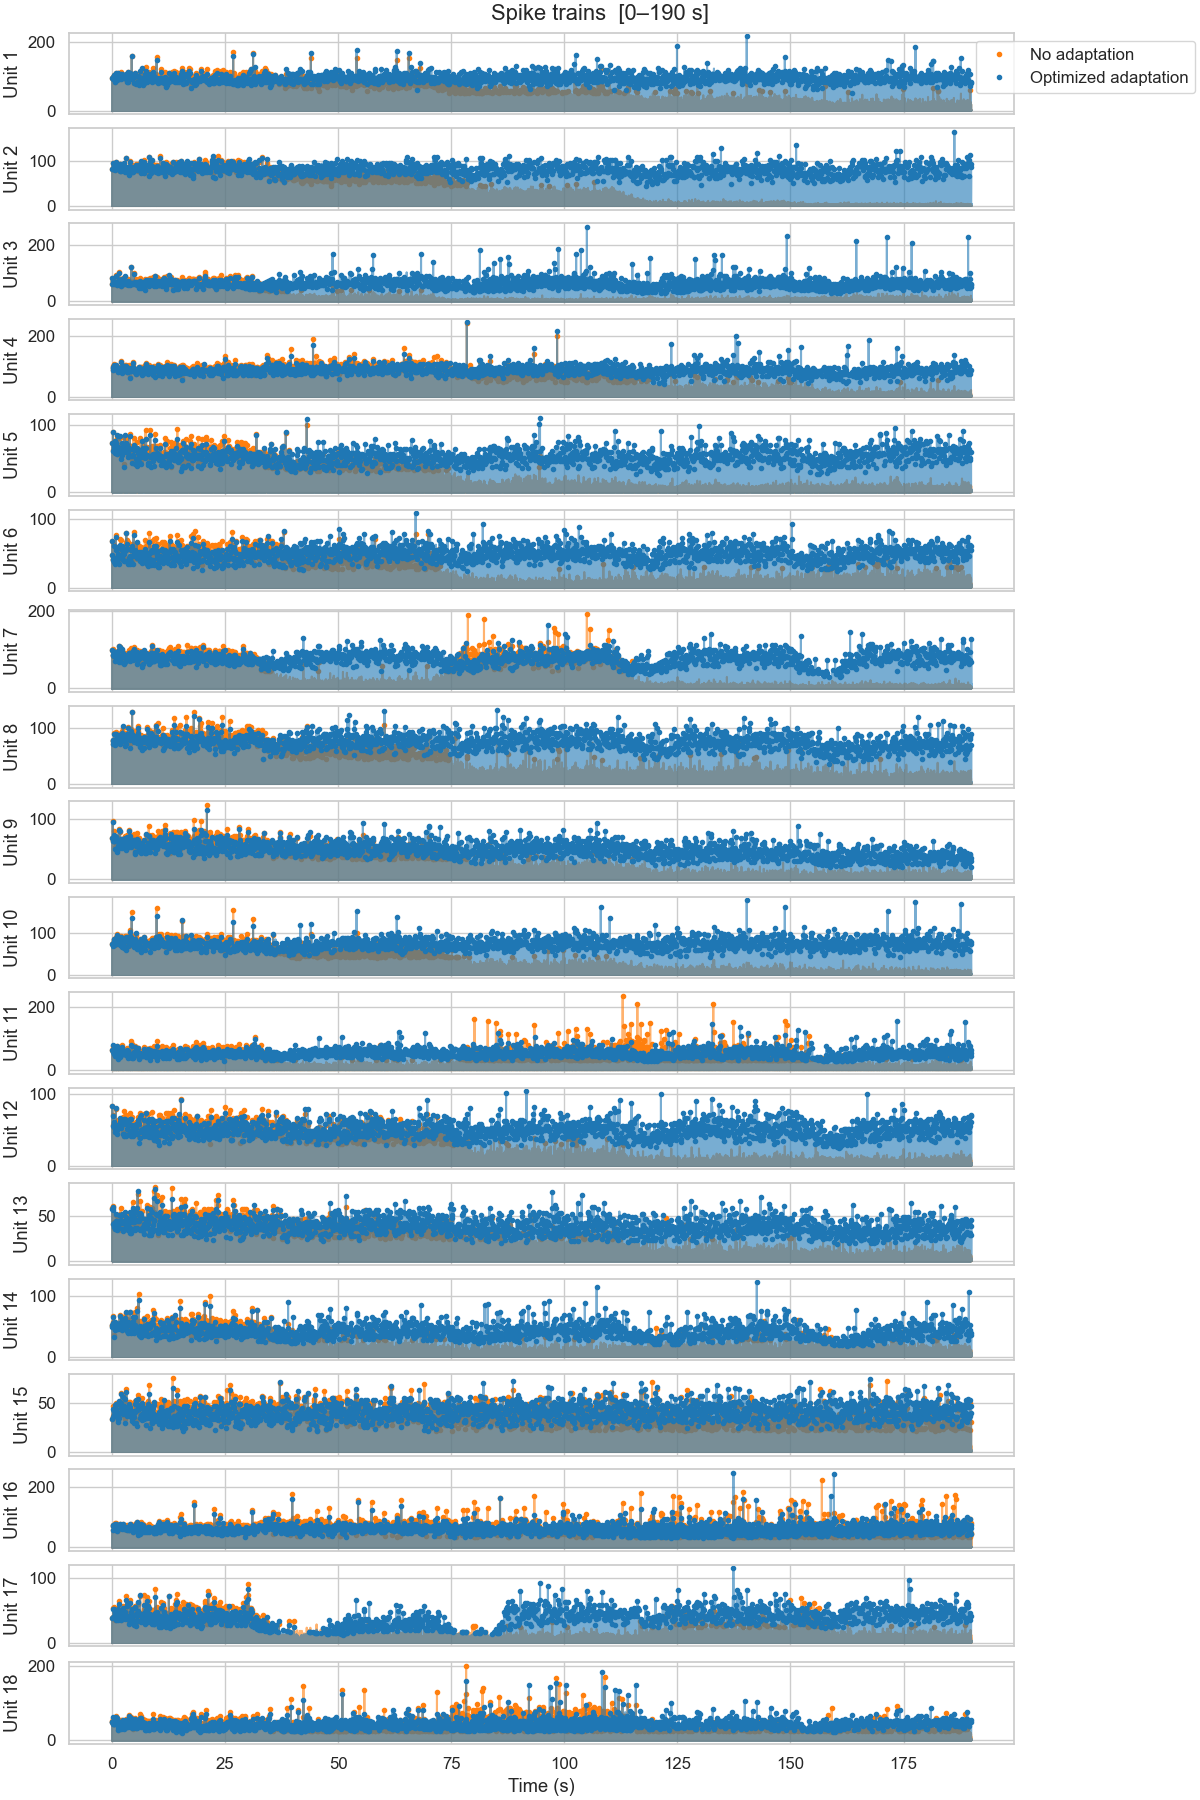

In [ ]:
t0, t1 = 0, 190
idxs = np.arange(int(t0 * data['fs']), int(t1 * data['fs']))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label, out in conditions.items():
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=colors[label], alpha=0.6)
        spike_mask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][spike_mask],
            ipts_sq[spike_mask],
            linestyle='None', marker='.', color=colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'Unit {u + 1}')

axs[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Spike trains  [{t0}–{t1} s]')
plt.show()

## 9. Multi-objective optimisation (source loss)

Instead of combining whitening and source quality into a single scalar, the two objectives are optimised separately using NSGA-II:
- **wh_loss**: median KL error² across batches (whitening quality)
- **source_loss**: nanmedian of contrast error² + centroid deviation² + (1 − SIL) (separation quality)

The result is a Pareto front. The operating point is selected by minimum sum of the two objectives; `study_mo.best_trials` exposes the full front for manual inspection.

In [ ]:
# cell-multiobjective-setup
_cfg_mo_path = RESULTS_DIR / 'best_config_mo.json'
_out_mo_path = RESULTS_DIR / 'out_mo.pt'

base_config_mo = {
    **{k: v for k, v in base_config.items()},
    'optim_loss':      'source',
    'log_source_loss': True,
    'log_wh_trace':    True,
}

if RUN_OPTIMISATION:
    out_mo, best_config_mo, study_mo = run_with_optimization(
        emg=data['emg'], whitening=data['whitening'], sep_vectors=data['sep_vectors'],
        base_centr=data['base_centr'], spikes_centr=data['spikes_centr'],
        emg_calib=data['emg_calib'], ipts_calib=data['ipts_calib'],
        spikes_calib=data['spikes_calib'],
        param_space=param_space,
        base_config=base_config_mo,
        n_trials=50,
        preprocess=data['preprocess'],
        optim_mode='multiobjective',
    )
    with open(_cfg_mo_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_mo.items()}, f, indent=2)
    torch.save(out_mo, _out_mo_path)
    print(f'Saved → {_cfg_mo_path}, {_out_mo_path}')
    print(f'Pareto front: {len(study_mo.best_trials)} trials')
else:
    with open(_cfg_mo_path) as f:
        best_config_mo = json.load(f)
    out_mo   = torch.load(_out_mo_path, weights_only=False)
    study_mo = None
    print(f'Loaded from {_cfg_mo_path}, {_out_mo_path}')

print('Selected config:')
for k, v in best_config_mo.items():
    if k in param_space:
        print(f'  {k}: {v:.4e}')

Saved → ../data/example/opt_results/best_config_mo.json, ../data/example/opt_results/out_mo.pt
Pareto front: 3 trials
Selected config:
  max_rel_delta_v: 2.7133e-03
  max_rel_delta_b: 4.0672e-02


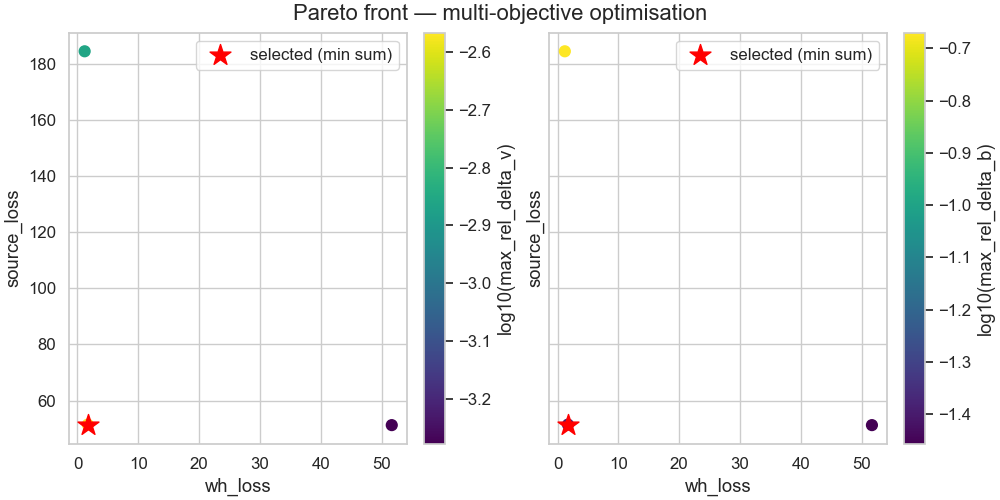

Pareto front size: 3 trials
Selected: wh_loss=1.7022, source_loss=51.4296


In [ ]:
# cell-pareto-front
if study_mo is None:
    print('Pareto front not available (results loaded from file).')
else:
    pareto_trials = study_mo.best_trials
    wh_vals  = [t.values[0] for t in pareto_trials]
    src_vals = [t.values[1] for t in pareto_trials]
    dv_vals  = [t.params.get('max_rel_delta_v', float('nan')) for t in pareto_trials]
    db_vals  = [t.params.get('max_rel_delta_b', float('nan')) for t in pareto_trials]
    sel_idx  = int(np.argmin([w + s for w, s in zip(wh_vals, src_vals)]))

    fig, ax = plt.subplots(1,2, figsize=(10, 5), layout='constrained', sharex=True, sharey=True)

    sc = ax[0].scatter(wh_vals, src_vals, c=np.log10(dv_vals), cmap='viridis', s=60, zorder=3)
    ax[0].scatter(wh_vals[sel_idx], src_vals[sel_idx], marker='*', s=250, color='red',
               zorder=4, label='selected (min sum)')
    plt.colorbar(sc, ax=ax[0], label='log10(max_rel_delta_v)')
    ax[0].set(xlabel='wh_loss', ylabel='source_loss')
    ax[0].legend()

    sc = ax[1].scatter(wh_vals, src_vals, c=np.log10(db_vals), cmap='viridis', s=60, zorder=3)
    ax[1].scatter(wh_vals[sel_idx], src_vals[sel_idx], marker='*', s=250, color='red',
               zorder=4, label='selected (min sum)')
    plt.colorbar(sc, ax=ax[1], label='log10(max_rel_delta_b)')
    ax[1].set(xlabel='wh_loss', ylabel='source_loss')
    ax[1].legend()

    plt.suptitle('Pareto front — multi-objective optimisation')
    plt.show()

    print(f'Pareto front size: {len(pareto_trials)} trials')
    print(f'Selected: wh_loss={wh_vals[sel_idx]:.4f}, source_loss={src_vals[sel_idx]:.4f}')

## 5. Loss trajectories

Both losses are z-scored by their calibration standard deviation (`sigma_K_cal` and `sigma_kappa_cal`), making them dimensionless and directly comparable. A loss near zero means the online statistics match calibration; large values indicate drift.

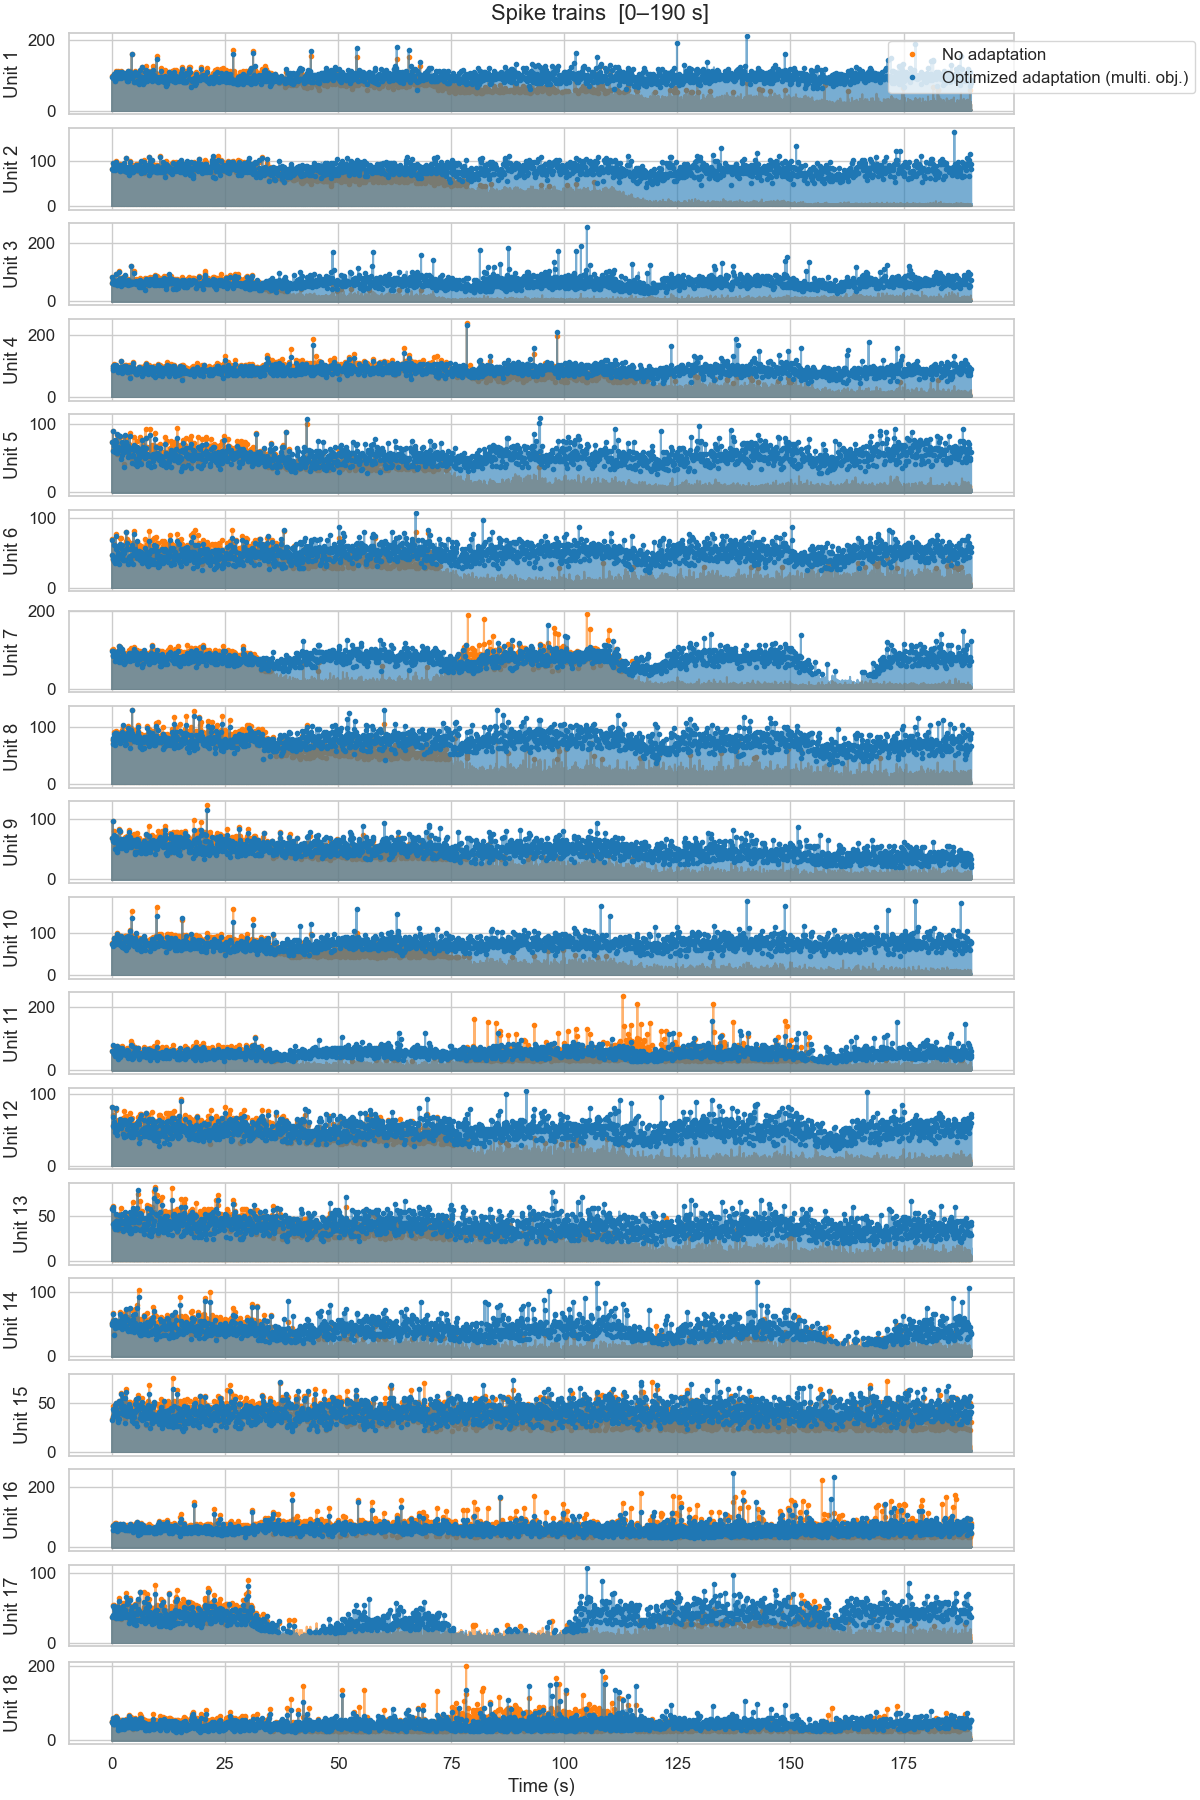

In [ ]:
conditions = {'No adaptation': out_no, 'Optimized adaptation (multi. obj.)': out_mo}
colors = {'No adaptation': 'tab:orange', 'Optimized adaptation (multi. obj.)': 'tab:blue'}


t0, t1 = 0, 190
idxs = np.arange(int(t0 * data['fs']), int(t1 * data['fs']))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label, out in conditions.items():
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=colors[label], alpha=0.6)
        spike_mask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][spike_mask],
            ipts_sq[spike_mask],
            linestyle='None', marker='.', color=colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'Unit {u + 1}')

axs[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Spike trains  [{t0}–{t1} s]')
plt.show()

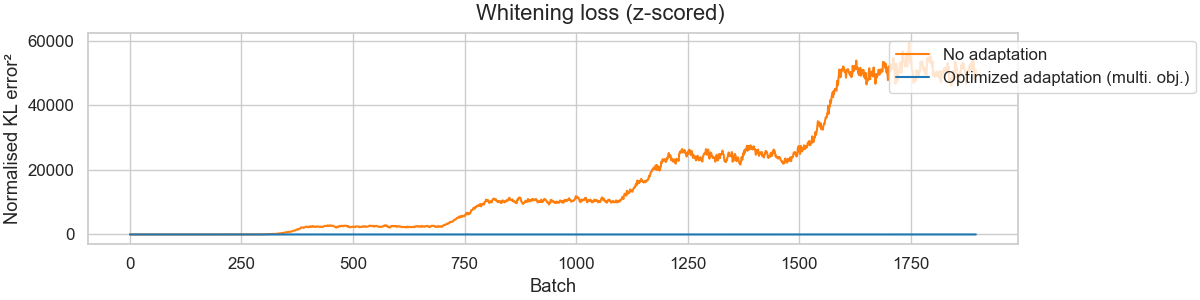

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label, out in conditions.items():
    ax.plot(out['wh_loss'][10:-1], label=label, color=colors[label])
ax.set(xlabel='Batch', ylabel='Normalised KL error²')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.suptitle('Whitening loss (z-scored)')
plt.show()

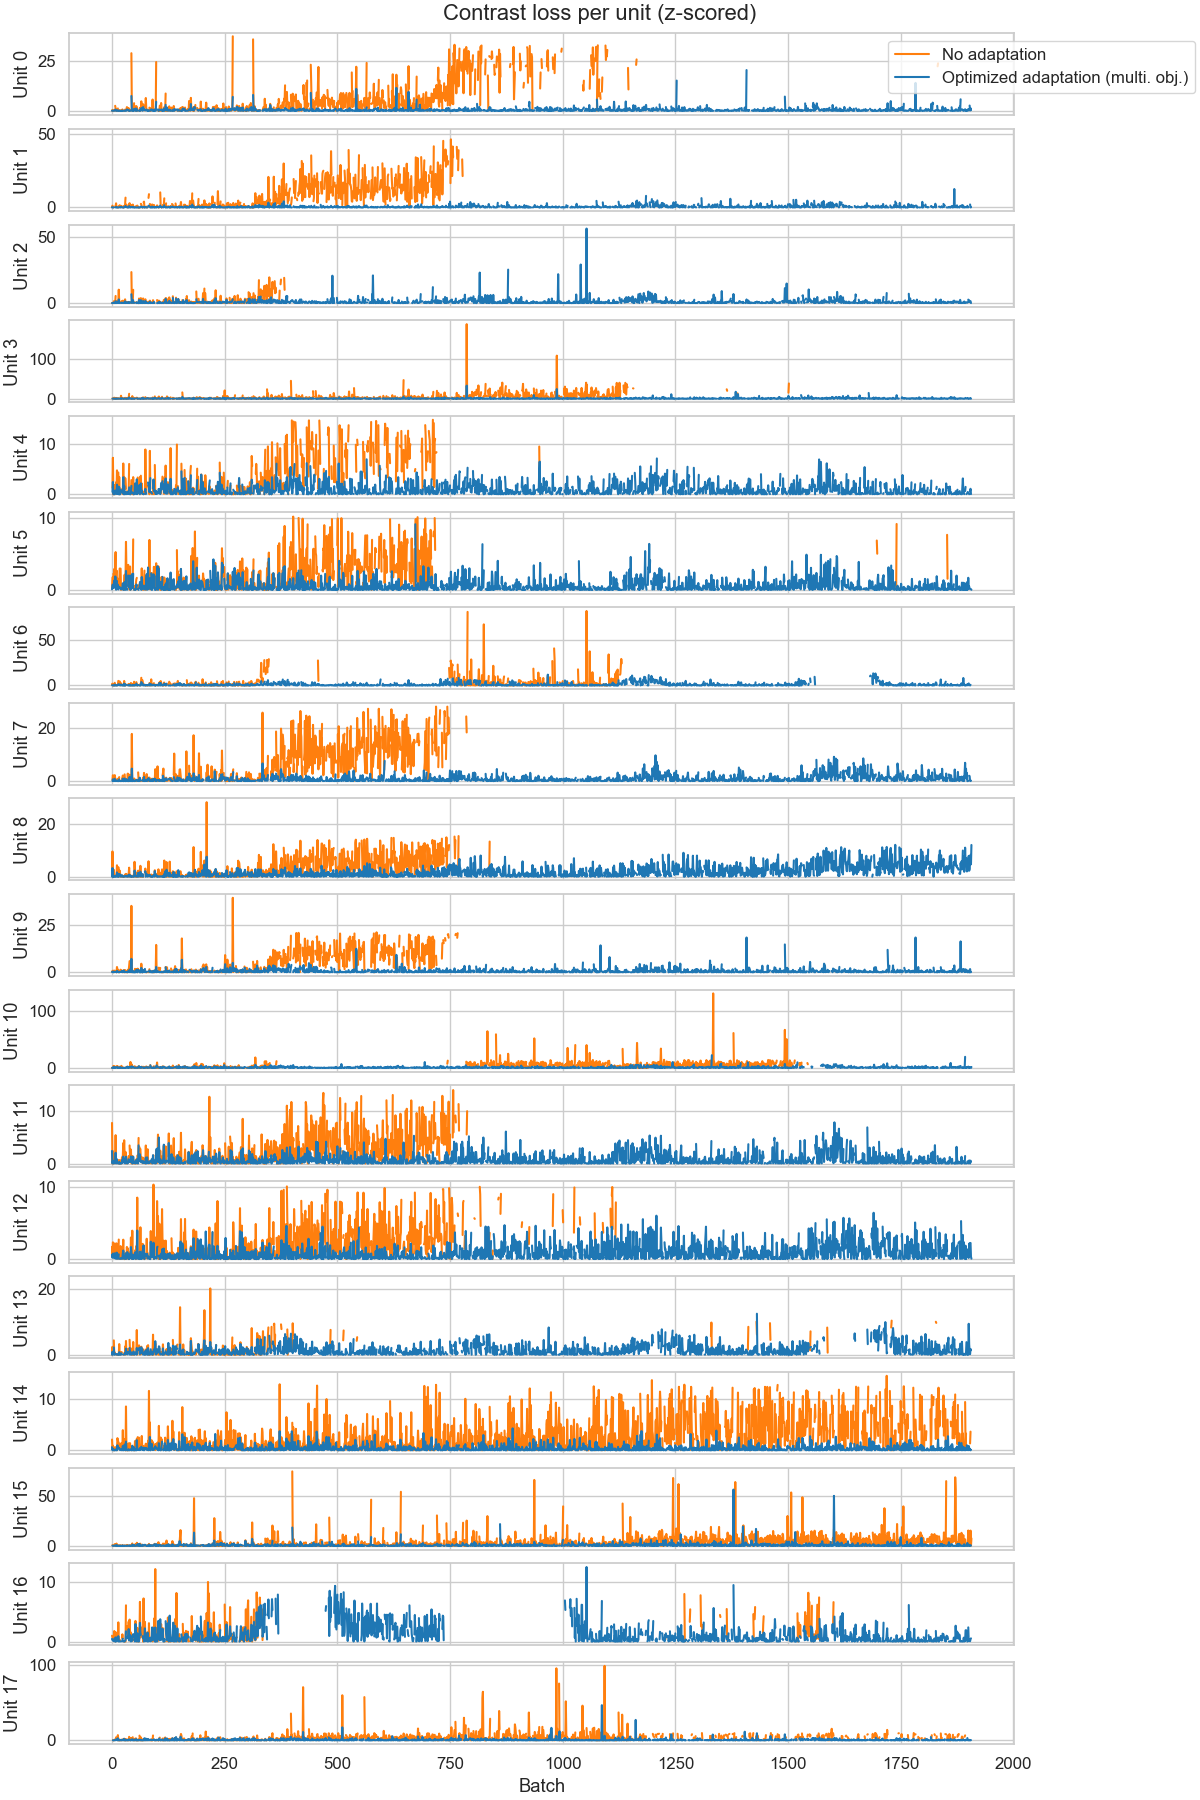

In [ ]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label, out in conditions.items():
        axs[u].plot(out['sv_loss'][:, u], label=label, color=colors[label])
    axs[u].set(ylabel=f'Unit {u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast loss per unit (z-scored)')
plt.show()

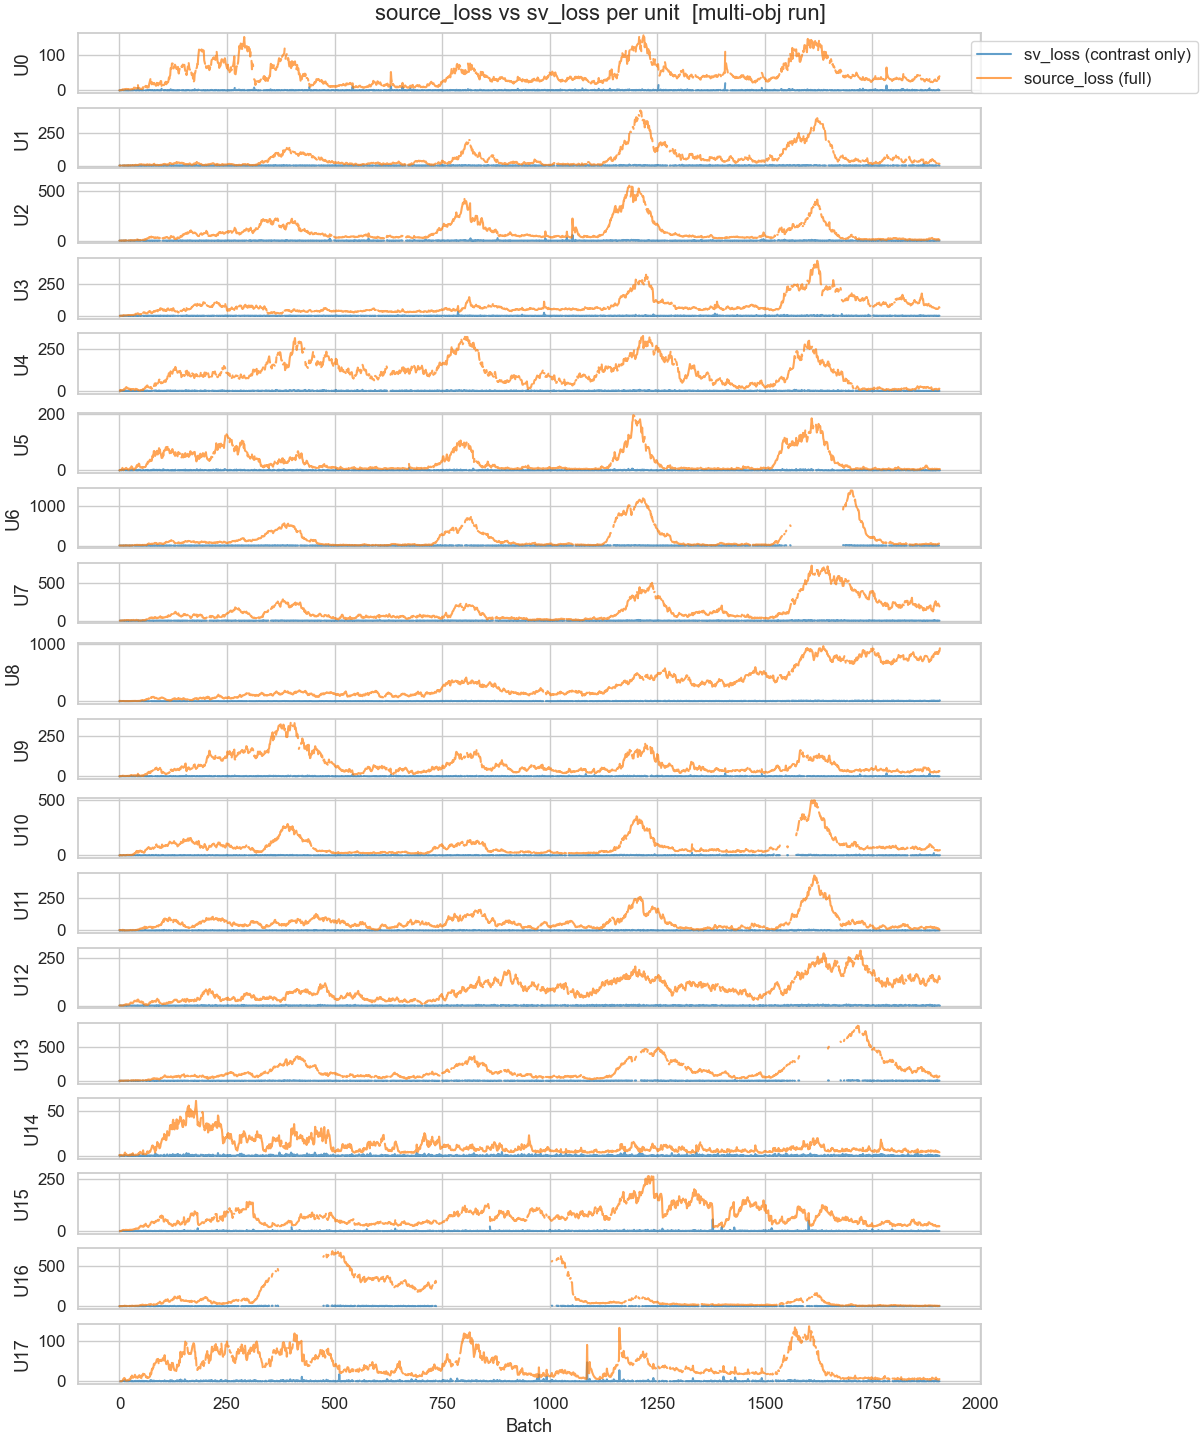

In [ ]:
# cell-source-loss-comparison
# source_loss (contrast + centroid + 1-SIL) vs. legacy sv_loss per unit
source_loss = out_mo['source_loss'].numpy()   # [batches, units]
sv_loss_mo  = out_mo['sv_loss'].numpy()

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units * 0.8), sharex=True, layout='constrained')
for u in range(n_units):
    axs[u].plot(sv_loss_mo[:, u],    label='sv_loss (contrast only)', color='tab:blue',   alpha=0.7)
    axs[u].plot(source_loss[:, u],   label='source_loss (full)',       color='tab:orange', alpha=0.7)
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('source_loss vs sv_loss per unit  [multi-obj run]')
plt.show()

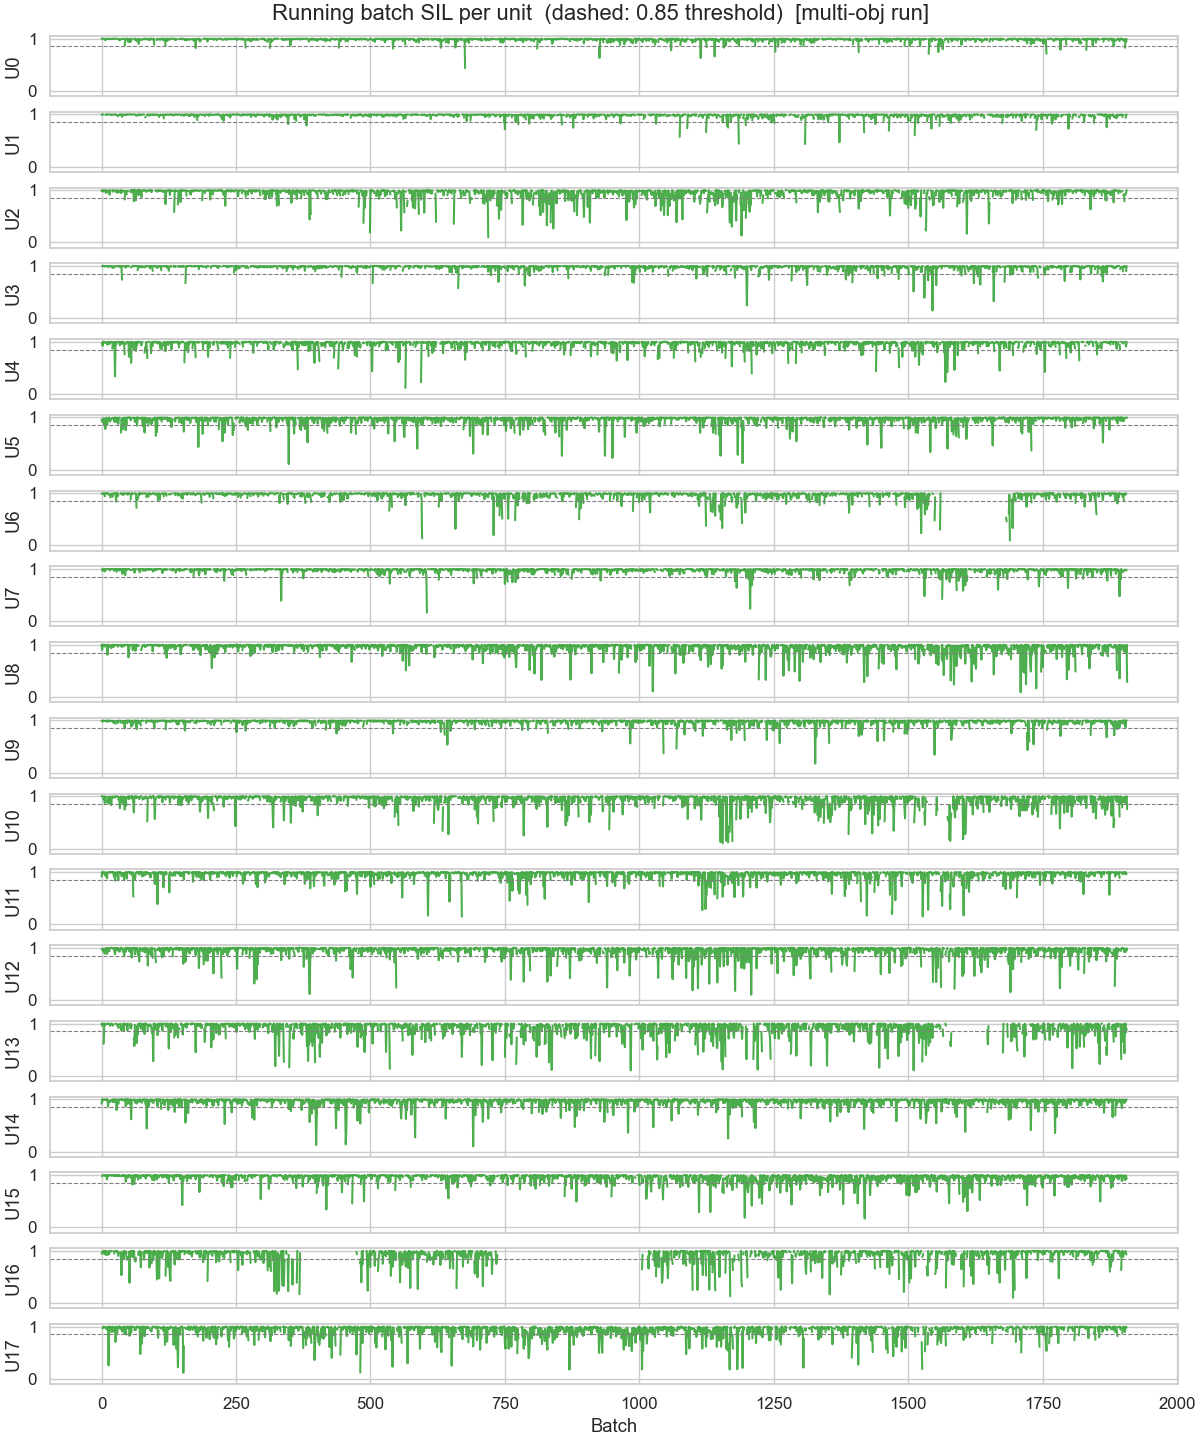

In [ ]:
# cell-sil-trajectory
# Per-unit running batch SIL over the full recording
import numpy as np

sil_loss = out_mo['sil_loss'].numpy()   # [batches, units], NaN where no spikes

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units * 0.8), sharex=True, layout='constrained')
for u in range(n_units):
    sil_u = sil_loss[:, u]
    valid = ~np.isnan(sil_u)
    axs[u].plot(np.where(valid, sil_u, np.nan), color='tab:green', alpha=0.85)
    axs[u].axhline(0.85, color='grey', linestyle='--', linewidth=0.8)
    axs[u].set(ylabel=f'U{u}', ylim=(-0.1, 1.05))
axs[-1].set(xlabel='Batch')
plt.suptitle('Running batch SIL per unit  (dashed: 0.85 threshold)  [multi-obj run]')
plt.show()

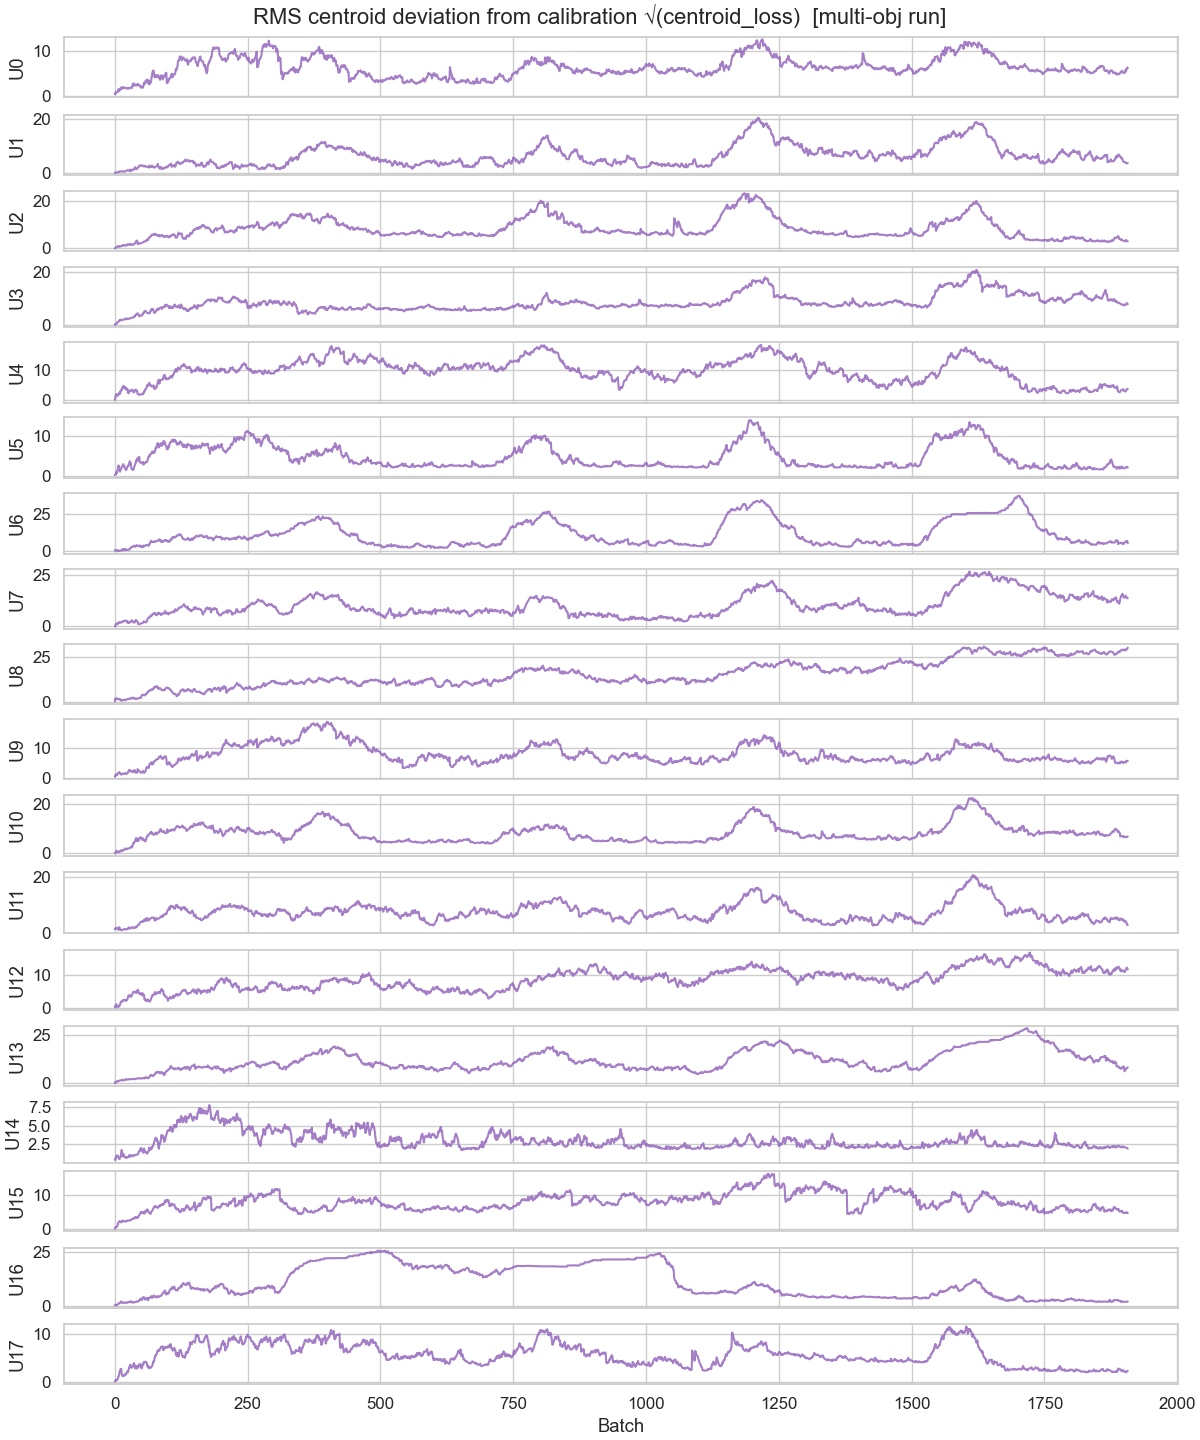

In [ ]:
# cell-centroid-loss-trajectory
# Per-unit centroid deviation from calibration over batches
centroid_loss = out_mo['centroid_loss'].numpy()   # [batches, units]
n_batches_mo  = centroid_loss.shape[0]

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units * 0.8), sharex=True, layout='constrained')
for u in range(n_units):
    axs[u].plot(np.sqrt(centroid_loss[:, u]), color='tab:purple', alpha=0.85)
    axs[u].set(ylabel=f'U{u}')
axs[-1].set(xlabel='Batch', ylabel=f'U{n_units - 1}')
plt.suptitle('RMS centroid deviation from calibration √(centroid_loss)  [multi-obj run]')
plt.show()

In [ ]:
# # cell-wh-loss-trace-comparison
# # Re-run both best configs with log_wh_trace=True (not stored in run() by default)
# def _run_with_wh_trace(data, cfg_dict):
#     cfg = Config()
#     for k, v in cfg_dict.items():
#         setattr(cfg, k, v)
#     cfg.log_wh_trace = True
#     dec = AdaptDecomp(
#         emg=data['emg'].clone(), whitening=data['whitening'].clone(),
#         sep_vectors=data['sep_vectors'].clone(), base_centr=data['base_centr'].clone(),
#         spikes_centr=data['spikes_centr'].clone(), emg_calib=data['emg_calib'].clone(),
#         ipts_calib=data['ipts_calib'].clone(), spikes_calib=data['spikes_calib'].clone(),
#         preprocess=data['preprocess'], config=cfg,
#     )
#     out = dec.run()
#     return out, dec.decomp.trace_cal.item()

# out_leg_tr, trace_cal = _run_with_wh_trace(data, best_config)
# out_mo_tr,  _         = _run_with_wh_trace(data, best_config_mo)

trace_ratio_leg = out_leg_tr['wh_trace'].numpy() / trace_cal
trace_ratio_mo  = out_mo_tr['wh_trace'].numpy()  / trace_cal

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True, layout='constrained')
axs[0].plot(out_leg_tr['wh_loss'].numpy()[10:], label='legacy single-obj', alpha=0.8)
axs[0].plot(out_mo_tr['wh_loss'].numpy()[10:],  label='multi-obj selected', alpha=0.8)
axs[0].set(ylabel='KL error²', title='Whitening loss')
axs[0].legend()

axs[1].plot(trace_ratio_leg[10:], label='legacy single-obj', alpha=0.8)
axs[1].plot(trace_ratio_mo[10:],  label='multi-obj selected', alpha=0.8)
for y, ls in [(0.1, '--'), (1.0, '-'), (10.0, '--')]:
    axs[1].axhline(y, color='grey', linestyle=ls, linewidth=0.8)
axs[1].set(ylabel='trace(Rz) / trace_cal', xlabel='Batch',
           title='Whitening trace ratio  (dashed: trace_check bounds 0.1 / 10)')
axs[1].legend()
plt.suptitle('Whitening diagnostics: legacy vs. multi-objective selected trial')
plt.show()

NameError: name 'out_leg_tr' is not defined

## 10. Decomposition quality metrics

Silhouette measure (SIL), pulse-to-noise ratio (PNR), discharge rate (DR), and coefficient of variation (CoV) compared across all three conditions.  
A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [ ]:
timestamps_np = data['timestamps'].numpy()
ext_fact      = data['ext_fact']

cond_labels  = ['No adaptation', 'Legacy (single-obj)', 'Multi-objective']
cond_colors  = {
    'No adaptation':       'tab:orange',
    'Legacy (single-obj)': 'tab:blue',
    'Multi-objective':     'tab:green',
}
cond_outputs = {
    'No adaptation':       out_no,
    'Legacy (single-obj)': out_opt,
    'Multi-objective':     out_mo,
}

rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps_np, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps_np, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr, dr_low_thr=5, dr_upp_thr=35,
                               cov_thr=0.35, sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
        .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')

In [ ]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)

ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] pps | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Decomposition quality: all conditions', fontsize=13)
plt.show()

## 11. Rate of agreement with ground truth

Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference. The bottom subplot shows whether each unit is classified as **good** (●) or **bad** (✗) under each condition, enabling direct correlation between separation quality and agreement with ground truth.

In [ ]:
cal_idx = np.arange(0, int(30 * data['fs']))

roa_no_cal,  pair_no,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_no['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)
roa_opt_cal, pair_opt, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_opt['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)
roa_mo_cal,  pair_mo,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_mo['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)

print(f'RoA calibration | No adaptation:       {roa_no_cal.mean()*100:.2f} ± {roa_no_cal.std()*100:.2f}%')
print(f'RoA calibration | Legacy (single-obj): {roa_opt_cal.mean()*100:.2f} ± {roa_opt_cal.std()*100:.2f}%')
print(f'RoA calibration | Multi-objective:     {roa_mo_cal.mean()*100:.2f} ± {roa_mo_cal.std()*100:.2f}%')

# No-adapt pairing is the reference across all conditions
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]

In [ ]:
roa_no_full,  _, _ = rate_of_agreement_paired(sim_spikes, out_no['spikes'].numpy(),  fs=data['fs'], tol_spike_ms=2)
roa_opt_full, _, _ = rate_of_agreement_paired(sim_spikes, out_opt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)
roa_mo_full,  _, _ = rate_of_agreement_paired(sim_spikes, out_mo['spikes'].numpy(),  fs=data['fs'], tol_spike_ms=2)

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

print(f'RoA full | No adaptation:       {roa_no_full.mean()*100:.2f} ± {roa_no_full.std()*100:.2f}%  (med: {np.median(roa_no_full)*100:.2f}%)')
print(f'RoA full | Legacy (single-obj): {roa_opt_full.mean()*100:.2f} ± {roa_opt_full.std()*100:.2f}%  (med: {np.median(roa_opt_full)*100:.2f}%)')
print(f'RoA full | Multi-objective:     {roa_mo_full.mean()*100:.2f} ± {roa_mo_full.std()*100:.2f}%  (med: {np.median(roa_mo_full)*100:.2f}%)')

# Good-unit lookup per condition
good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_roa.plot(x, roa_no_full  * 100, marker='o', label='No adaptation',       color=cond_colors['No adaptation'])
ax_roa.plot(x, roa_opt_full * 100, marker='o', label='Legacy (single-obj)', color=cond_colors['Legacy (single-obj)'])
ax_roa.plot(x, roa_mo_full  * 100, marker='o', label='Multi-objective',     color=cond_colors['Multi-objective'])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

# Good/bad subplot: one marker per (condition, unit); ● = good, ✗ = bad
y_pos = {'No adaptation': 2, 'Legacy (single-obj)': 1, 'Multi-objective': 0}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification')
ax_good.grid(axis='x', alpha=0.3)

plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()